In [ ]:
import sys
sys.path.append("../../../src")


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [20]:
df = pd.read_csv('../../../data/raw/Life Expectancy Data.csv')
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [21]:
df.columns = (
    df.columns
    .str.strip()             
    .str.replace("  ", " ")   
)


In [22]:
print(f"Número de linhas: {df.shape[0]}")
print(f"Número de colunas: {df.shape[1]}")

Número de linhas: 2938
Número de colunas: 22


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10  BMI                              2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

In [24]:
df.isnull().sum()

Country                              0
Year                                 0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
BMI                                 34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
HIV/AIDS                             0
GDP                                448
Population                         652
thinness 1-19 years                 34
thinness 5-9 years                  34
Income composition of resources    167
Schooling                          163
dtype: int64

Análise Exploratória dos dados

In [25]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Year,2938.0,2.007519e+03,4.613841e+00,2000.00000,2004.000000,2.008000e+03,2.012000e+03,2.015000e+03
Life expectancy,2928.0,6.922493e+01,9.523867e+00,36.30000,63.100000,7.210000e+01,7.570000e+01,8.900000e+01
Adult Mortality,2928.0,1.647964e+02,1.242921e+02,1.00000,74.000000,1.440000e+02,2.280000e+02,7.230000e+02
infant deaths,2938.0,3.030395e+01,1.179265e+02,0.00000,0.000000,3.000000e+00,2.200000e+01,1.800000e+03
Alcohol,2744.0,4.602861e+00,4.052413e+00,0.01000,0.877500,3.755000e+00,7.702500e+00,1.787000e+01
percentage expenditure,2938.0,7.382513e+02,1.987915e+03,0.00000,4.685343,6.491291e+01,4.415341e+02,1.947991e+04
Hepatitis B,2385.0,8.094046e+01,2.507002e+01,1.00000,77.000000,9.200000e+01,9.700000e+01,9.900000e+01
Measles,2938.0,2.419592e+03,1.146727e+04,0.00000,0.000000,1.700000e+01,3.602500e+02,2.121830e+05
BMI,2904.0,3.832125e+01,2.004403e+01,1.00000,19.300000,4.350000e+01,5.620000e+01,8.730000e+01
under-five deaths,2938.0,4.203574e+01,1.604455e+02,0.00000,0.000000,4.000000e+00,2.800000e+01,2.500000e+03


In [27]:
missing = df.isna().sum().sort_values(ascending=False)

missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Ausentes": missing,
    "%": missing_percent
})

missing_df


,Ausentes,%
Population,652,22.191967
Hepatitis B,553,18.822328
GDP,448,15.248468
Total expenditure,226,7.692308
Alcohol,194,6.603131
Income composition of resources,167,5.684139
Schooling,163,5.547992
thinness 1-19 years,34,1.157250
thinness 5-9 years,34,1.157250
BMI,34,1.157250


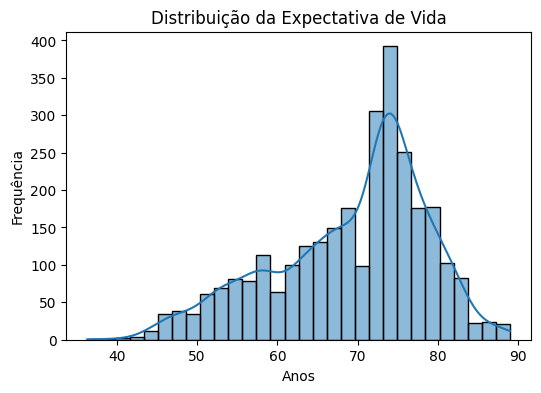

In [28]:
plt.figure(figsize=(6,4))
sns.histplot(df["Life expectancy"], kde=True)
plt.title("Distribuição da Expectativa de Vida")
plt.xlabel("Anos")
plt.ylabel("Frequência")
plt.show()


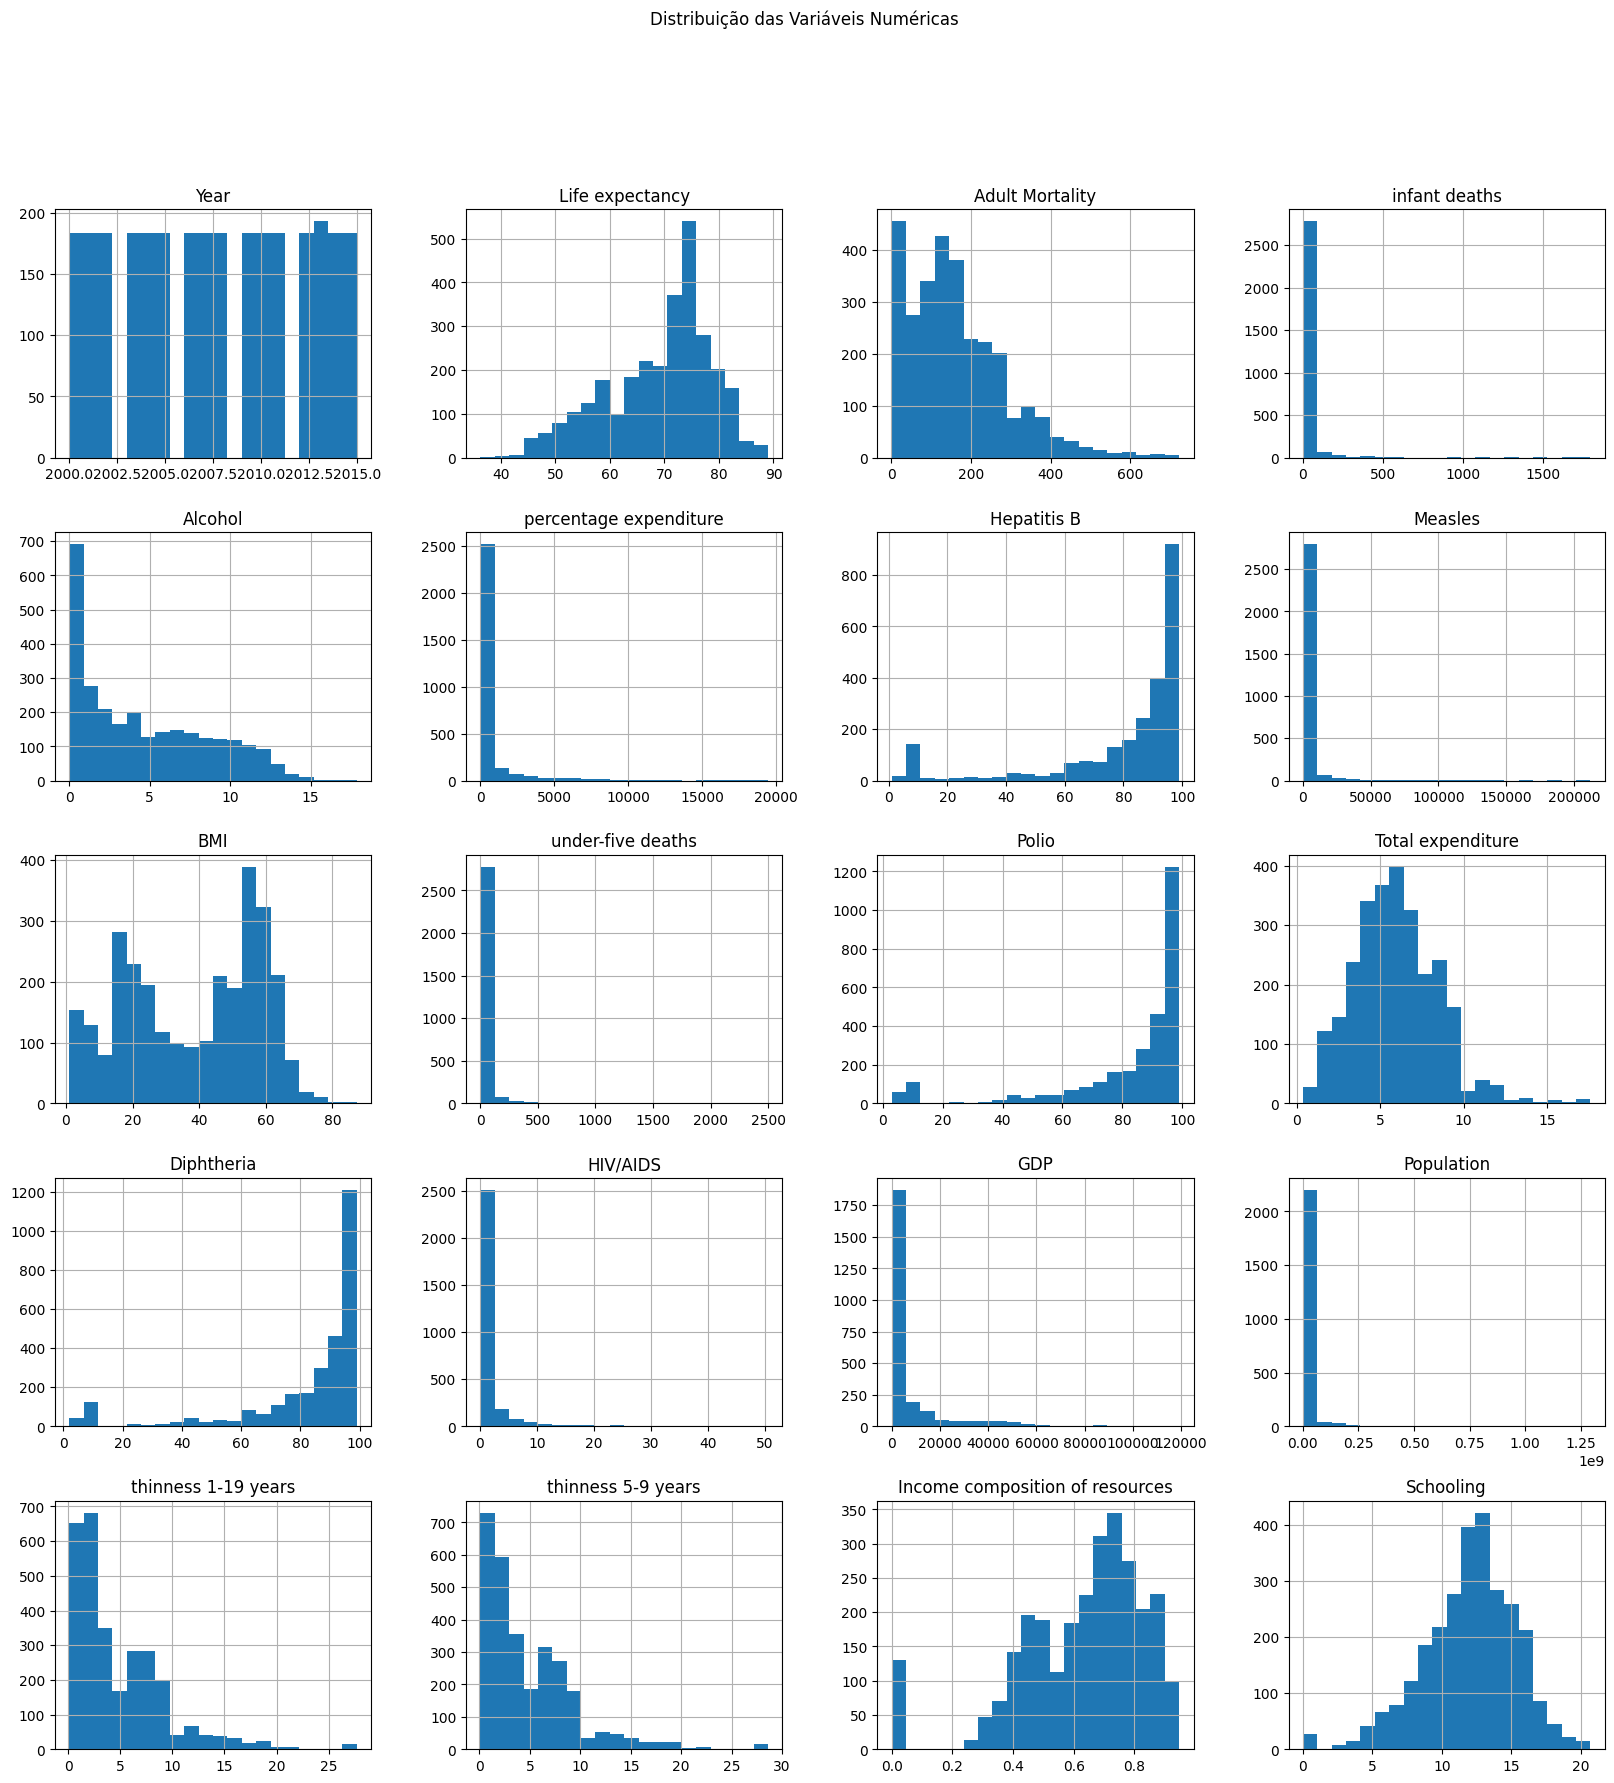

In [29]:
df.hist(figsize=(20, 20), bins=20)
plt.suptitle("Distribuição das Variáveis Numéricas")
plt.show()


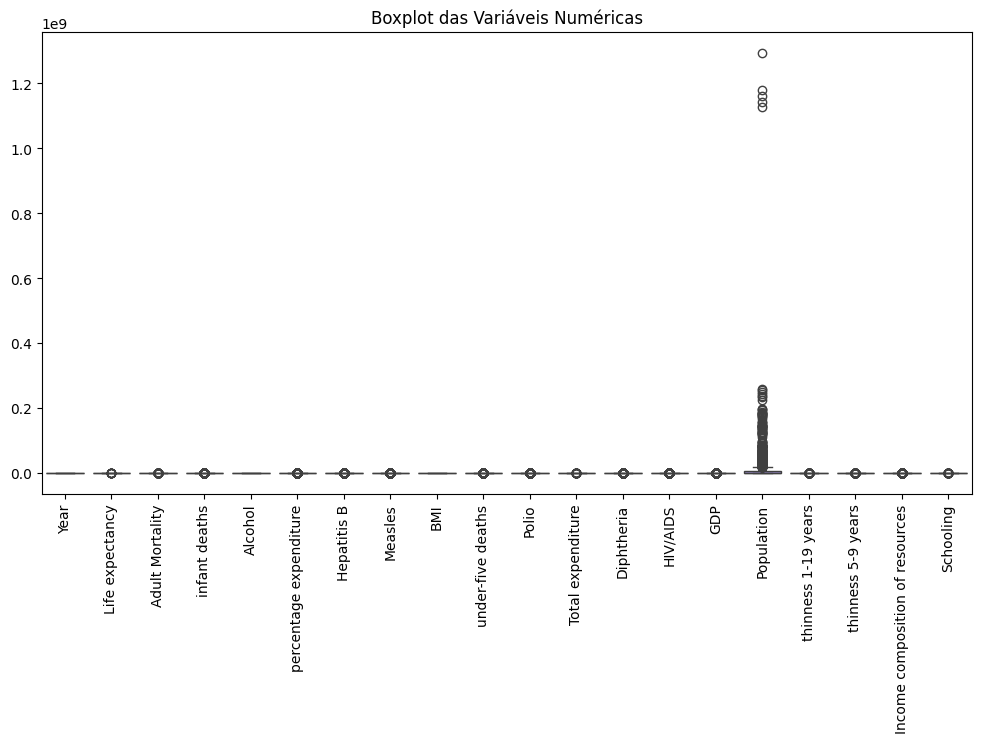

In [30]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df.select_dtypes(include=["float64", "int64"]))
plt.xticks(rotation=90)
plt.title("Boxplot das Variáveis Numéricas")
plt.show()


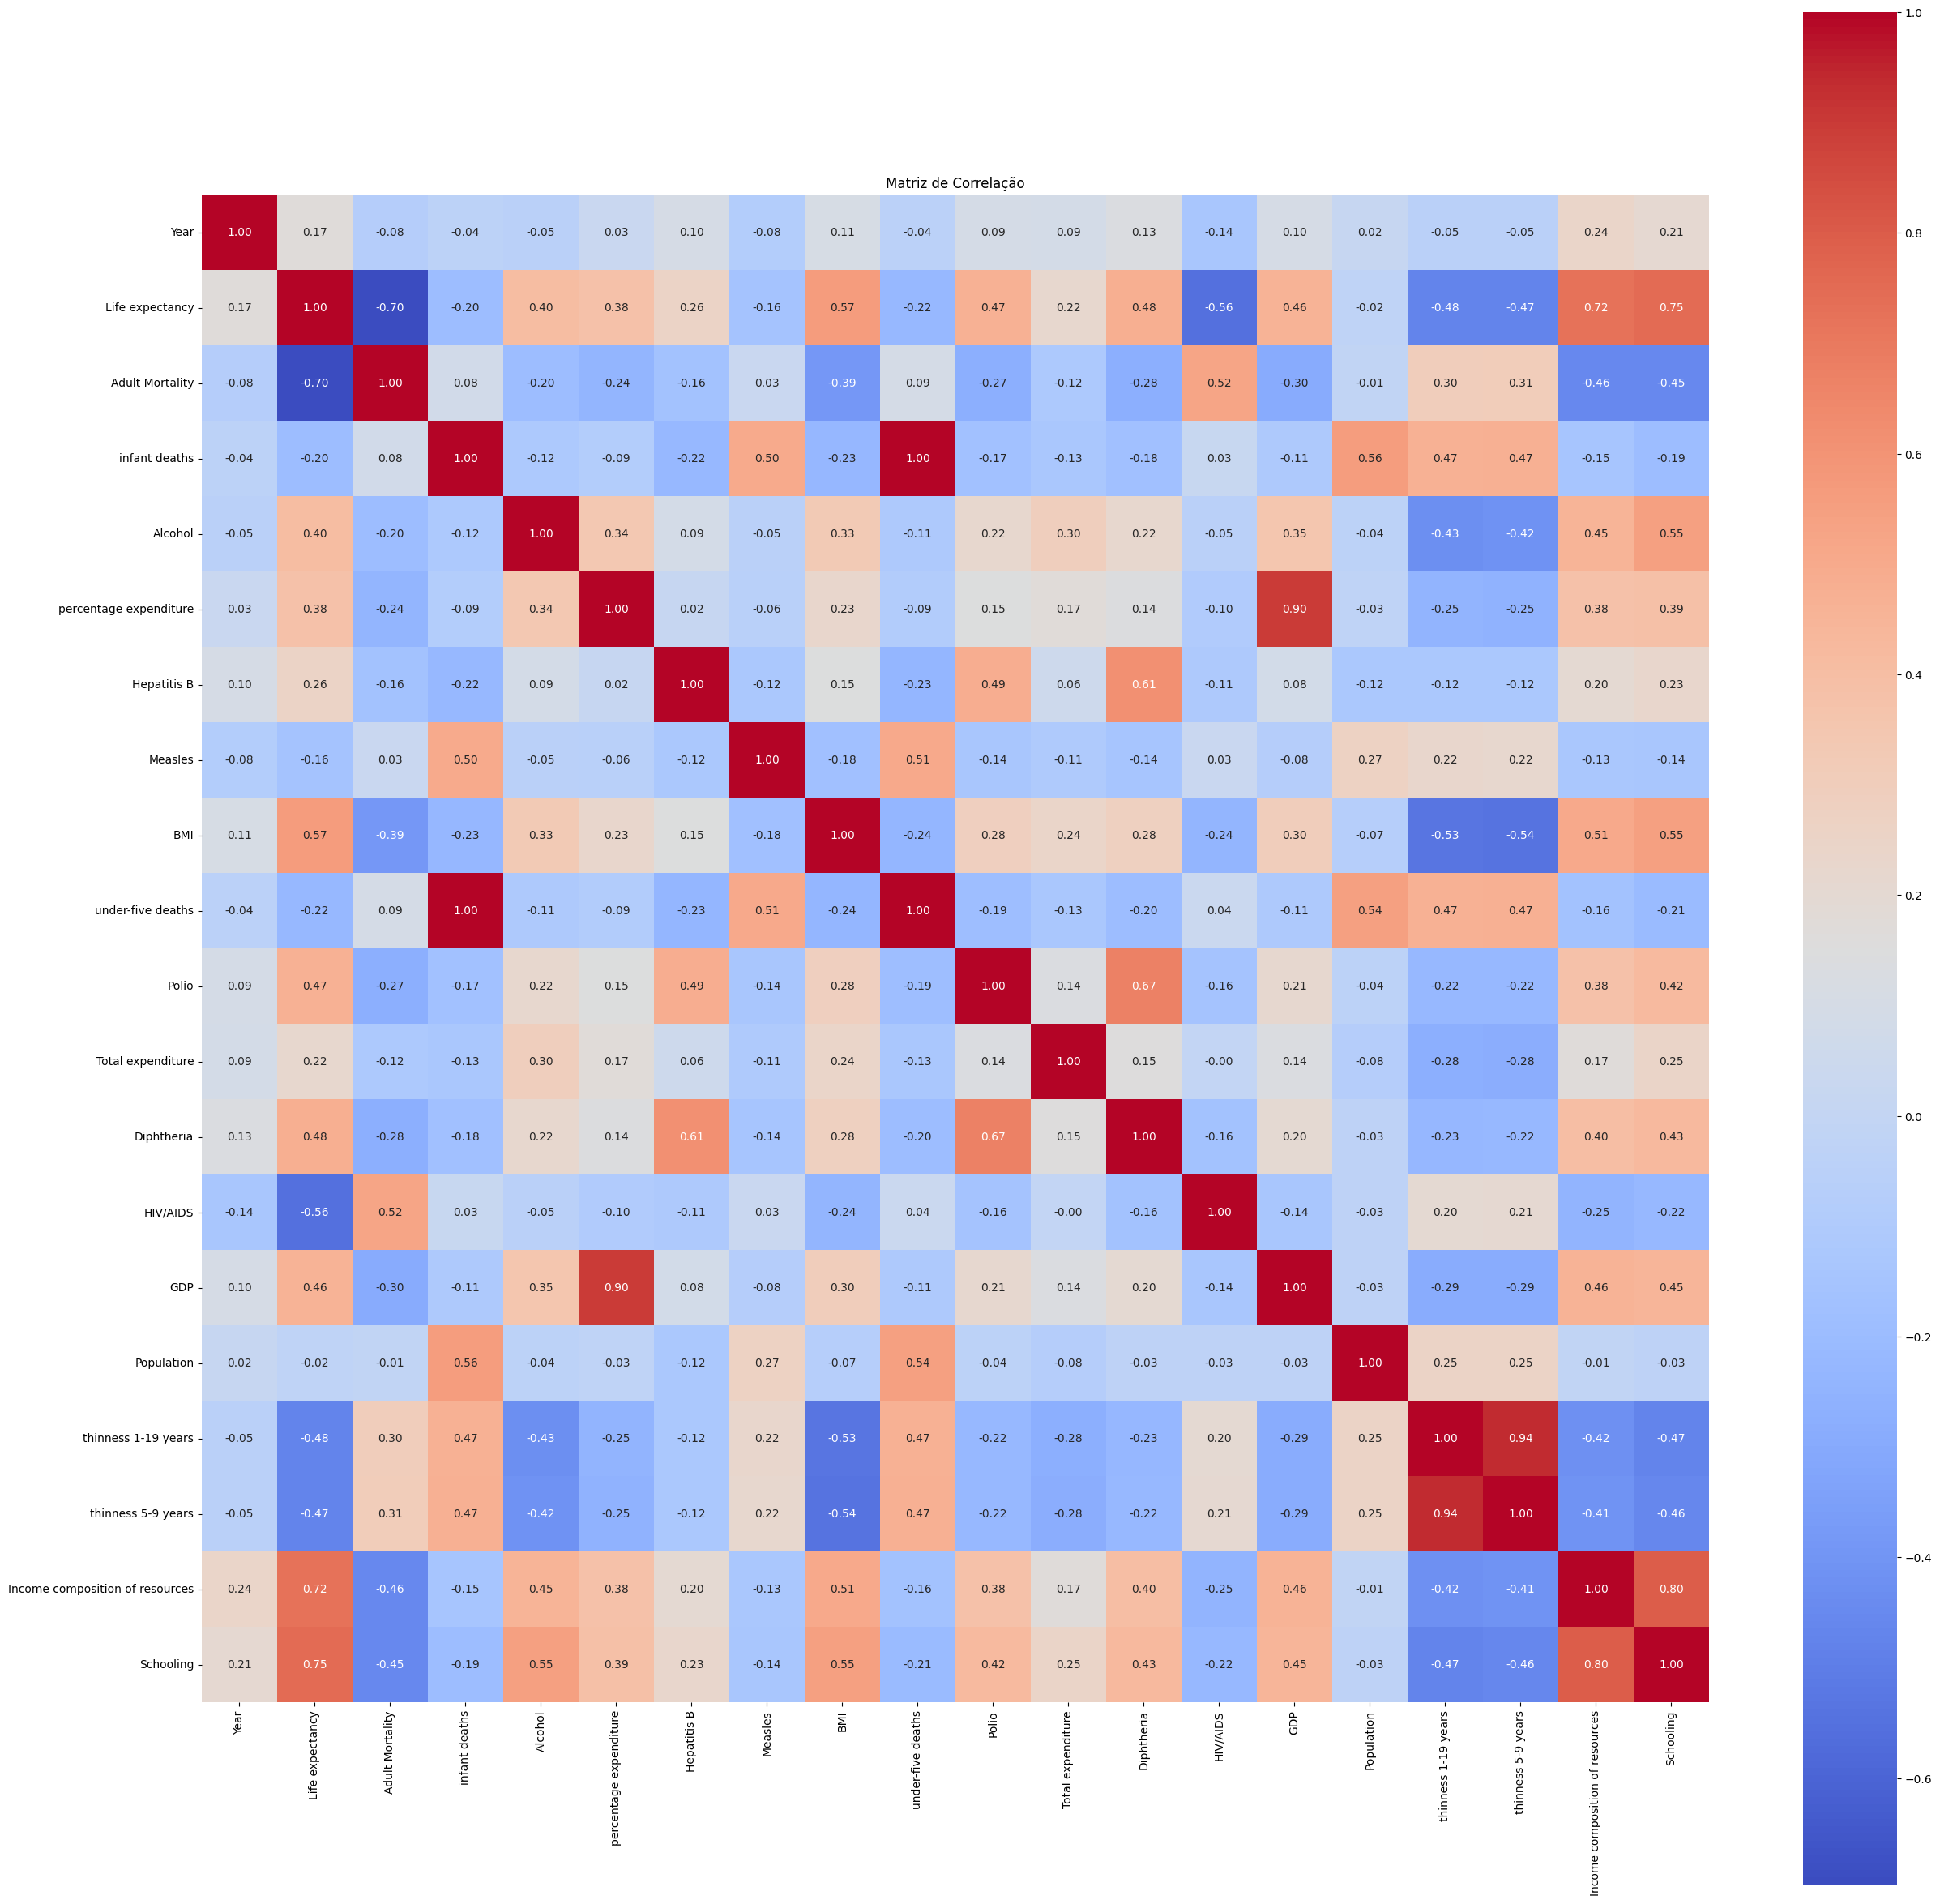

In [32]:
df_numeric = df.select_dtypes(include=['int64', 'float64'])

corr_matrix = df_numeric.corr()

plt.figure(figsize=(30, 30))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True
)
plt.title("Matriz de Correlação")
plt.show()



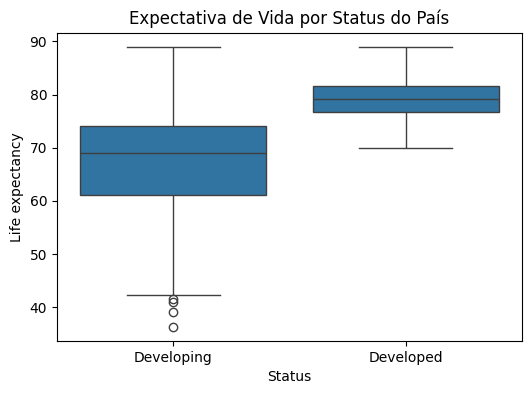

In [33]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Status", y="Life expectancy", data=df)
plt.title("Expectativa de Vida por Status do País")
plt.show()


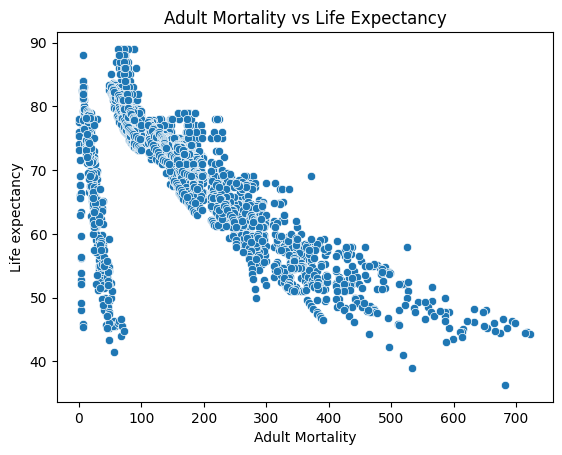

In [36]:
sns.scatterplot(
    x="Adult Mortality",
    y="Life expectancy",
    data=df
)
plt.title("Adult Mortality vs Life Expectancy")
plt.show()


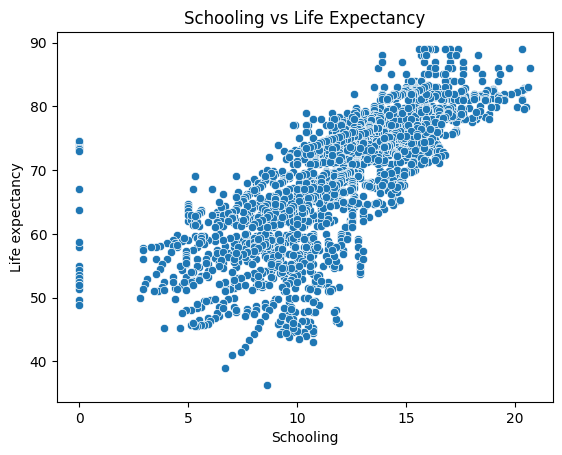

In [34]:
sns.scatterplot(
    x="Schooling",
    y="Life expectancy",
    data=df
)
plt.title("Schooling vs Life Expectancy")
plt.show()


In [37]:
df.columns = df.columns.str.strip()


In [38]:
df = df.drop(columns=["Country"])


In [39]:
df = df.dropna(subset=["Life expectancy"])


In [40]:
y = df["Life expectancy"]
X = df.drop(columns=["Life expectancy"])


In [41]:
from sklearn.impute import SimpleImputer

num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns


In [42]:
df = df.dropna(subset=["Life expectancy"])


In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [44]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Pipeline numérico
num_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Pipeline categórico
cat_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combinação
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, num_cols),
        ("cat", cat_pipeline, cat_cols)
    ]
)


In [45]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

X_train_processed.shape, X_test_processed.shape


((2342, 21), (586, 21))

In [46]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


In [47]:
from sklearn.dummy import DummyRegressor

dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train_processed, y_train)

y_pred_dummy = dummy.predict(X_test_processed)

mae_dummy = mean_absolute_error(y_test, y_pred_dummy)
rmse_dummy = np.sqrt(mean_squared_error(y_test, y_pred_dummy))
r2_dummy = r2_score(y_test, y_pred_dummy)

mae_dummy, rmse_dummy, r2_dummy


(7.676658321262128, np.float64(9.308237114515464), -0.0016633162021579828)

In [48]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_processed, y_train)

y_pred_lr = lr.predict(X_test_processed)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

mae_lr, rmse_lr, r2_lr


(2.927326916023633, np.float64(3.9514833389733646), 0.8194875321804443)

In [49]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_processed, y_train)

y_pred_ridge = ridge.predict(X_test_processed)

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

mae_ridge, rmse_ridge, r2_ridge


(2.926835451714584, np.float64(3.9539808279826802), 0.8192592784660793)

In [50]:
baseline_results = pd.DataFrame({
    "Modelo": ["Dummy", "Regressão Linear", "Ridge"],
    "MAE": [mae_dummy, mae_lr, mae_ridge],
    "RMSE": [rmse_dummy, rmse_lr, rmse_ridge],
    "R²": [r2_dummy, r2_lr, r2_ridge]
})

baseline_results


,Modelo,MAE,RMSE,R²
0,Dummy,7.676658,9.308237,-0.001663
1,Regressão Linear,2.927327,3.951483,0.819488
2,Ridge,2.926835,3.953981,0.819259


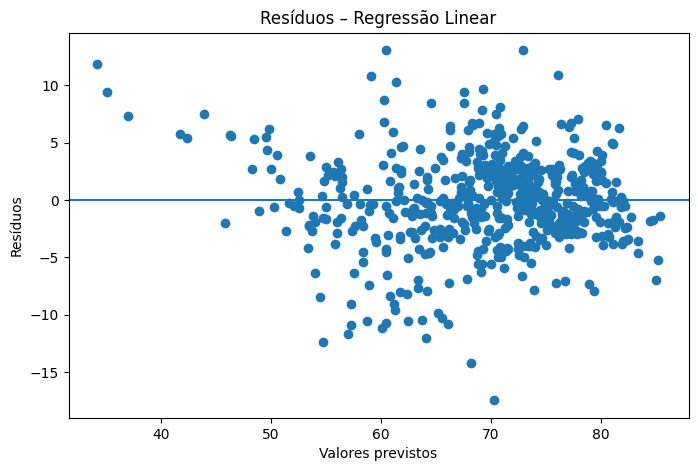

In [51]:
import matplotlib.pyplot as plt

residuals = y_test - y_pred_lr

plt.figure(figsize=(8, 5))
plt.scatter(y_pred_lr, residuals)
plt.axhline(0)
plt.xlabel("Valores previstos")
plt.ylabel("Resíduos")
plt.title("Resíduos – Regressão Linear")
plt.show()


In [52]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_processed, y_train)

y_pred_rf = rf.predict(X_test_processed)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

mae_rf, rmse_rf, r2_rf


(1.0513583617747437, np.float64(1.6923607940292238), 0.9668889613076994)

In [53]:
final_results = pd.DataFrame({
    "Modelo": ["Dummy", "Linear", "Ridge", "Random Forest"],
    "MAE": [mae_dummy, mae_lr, mae_ridge, mae_rf],
    "RMSE": [rmse_dummy, rmse_lr, rmse_ridge, rmse_rf],
    "R²": [r2_dummy, r2_lr, r2_ridge, r2_rf]
})

final_results


,Modelo,MAE,RMSE,R²
0,Dummy,7.676658,9.308237,-0.001663
1,Linear,2.927327,3.951483,0.819488
2,Ridge,2.926835,3.953981,0.819259
3,Random Forest,1.051358,1.692361,0.966889


In [54]:
importances = rf.feature_importances_

feature_importance = pd.DataFrame({
    "Variável": preprocessor.get_feature_names_out(),
    "Importância": importances
}).sort_values(by="Importância", ascending=False)

feature_importance.head(10)


,Variável,Importância
12,num__HIV/AIDS,0.597022
17,num__Income composition of resources,0.170818
1,num__Adult Mortality,0.124295
7,num__BMI,0.019054
8,num__under-five deaths,0.015908
18,num__Schooling,0.010622
16,num__thinness 5-9 years,0.009166
3,num__Alcohol,0.007522
0,num__Year,0.007315
15,num__thinness 1-19 years,0.005302


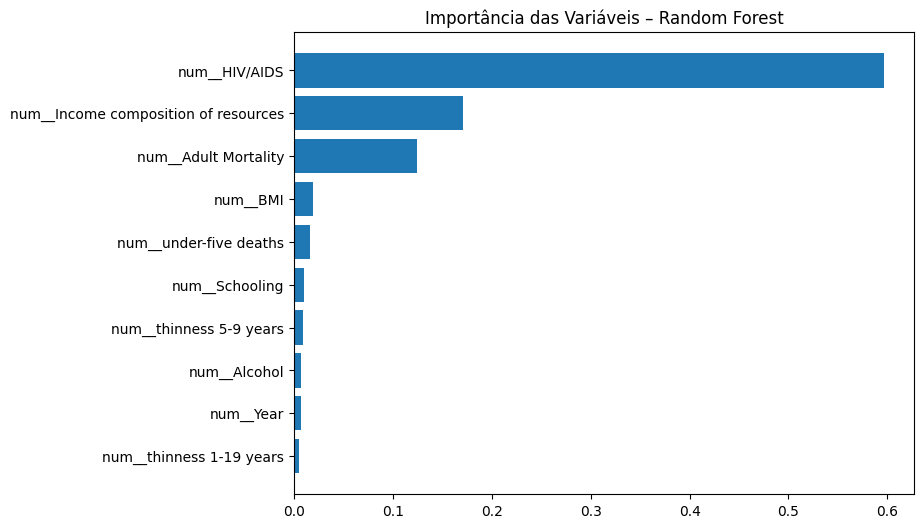

In [55]:
plt.figure(figsize=(8, 6))
plt.barh(
    feature_importance["Variável"][:10],
    feature_importance["Importância"][:10]
)
plt.gca().invert_yaxis()
plt.title("Importância das Variáveis – Random Forest")
plt.show()


In [56]:
from sklearn.model_selection import cross_val_score

cv_scores_lr = cross_val_score(
    lr,
    X_train_processed,
    y_train,
    cv=5,
    scoring="r2"
)

cv_scores_lr.mean(), cv_scores_lr.std()


(np.float64(0.8144480921854717), np.float64(0.0054056742720554095))

In [57]:
from sklearn.model_selection import GridSearchCV

param_grid_ridge = {
    "alpha": [0.01, 0.1, 1, 10, 100]
}

grid_ridge = GridSearchCV(
    Ridge(),
    param_grid_ridge,
    cv=5,
    scoring="r2"
)

grid_ridge.fit(X_train_processed, y_train)

grid_ridge.best_params_, grid_ridge.best_score_


({'alpha': 0.1}, np.float64(0.8144684566085898))

In [58]:
param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid_rf,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_rf.fit(X_train_processed, y_train)

grid_rf.best_params_, grid_rf.best_score_


({'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200},
 np.float64(0.9587387487096855))